In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/hamzarizwan765/musikall/id_genres.csv
/kaggle/input/datasets/hamzarizwan765/musikall/id_metadata.csv
/kaggle/input/datasets/hamzarizwan765/musikall/id_lang.csv
/kaggle/input/datasets/hamzarizwan765/musikall/id_tags.csv
/kaggle/input/datasets/hamzarizwan765/musikall/listening_history.csv
/kaggle/input/datasets/hamzarizwan765/musikall/id_information.csv


In [2]:
!pip install lightgbm matplotlib numpy pandas python-dotenv scipy scikit-learn


  SPOTIFY REPEAT PLAY PREDICTION — PIPELINE

[1/8] Loading data...
Loading CSV files...
  ✅ /kaggle/input/datasets/hamzarizwan765/musikall/listening_history.csv → 5,109,592 rows, 3 cols
  ✅ /kaggle/input/datasets/hamzarizwan765/musikall/id_genres.csv →  109,269 rows, 2 cols
  ✅ /kaggle/input/datasets/hamzarizwan765/musikall/id_tags.csv →  109,269 rows, 2 cols
  ✅ /kaggle/input/datasets/hamzarizwan765/musikall/id_metadata.csv →  109,269 rows, 11 cols
  ✅ /kaggle/input/datasets/hamzarizwan765/musikall/id_lang.csv →  109,269 rows, 2 cols

[2/8] Preprocessing history...
  Events: 5,058,234 | Users: 14,125 | Songs: 80,735
  Date range: 2013-12-30 → 2019-03-26

[3/8] Building target variable...
Building labels...
  Pairs: 2,554,231 | Repeat=1: 830,620 (32.5%)

[4/8] Building collaborative features...
  Collaborative features added → shape (2554231, 13)

[5/8] Building temporal features...
  Temporal features added → shape (2554231, 18)

[6/8] Building content features...
  Content features 

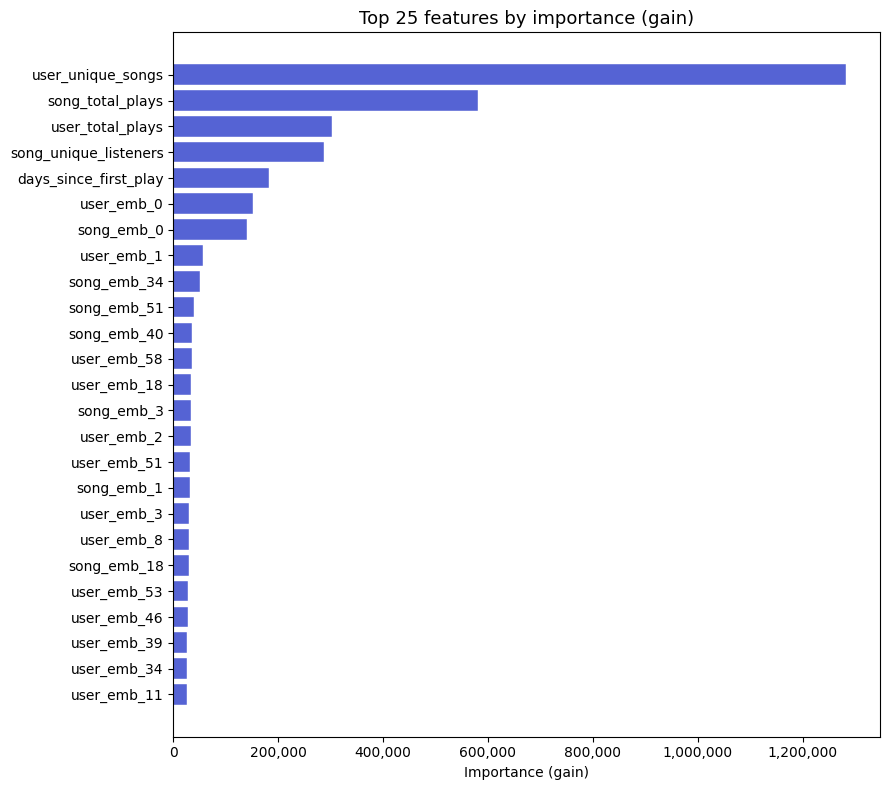

  Predictions saved → ./model_outputs/test_predictions.csv

[RECOMMENDATIONS]
  Top 10 for user: user_007XIjOr
         user             song  repeat_prob  label
user_007XIjOr XwHo5axzNm4n3UHD     0.865428      1
user_007XIjOr ANgqdprgC44Bj6Bv     0.854153      1
user_007XIjOr sFjtquf2sdK7R1ee     0.823972      1
user_007XIjOr jH2ACbKWbK1AlGLB     0.818142      1
user_007XIjOr b96WKRPEZcQvC69D     0.804568      1
user_007XIjOr NVwWvPLsUbIgyUii     0.802819      1
user_007XIjOr 85vIEgooVsqvVxRK     0.789254      1
user_007XIjOr zXMHUt57MEYgpgIz     0.787005      1
user_007XIjOr sKKgabkwl44SoTR7     0.783910      1
user_007XIjOr D098jupnftqfLnvL     0.778791      1

✅ Pipeline complete.


In [3]:
# ============================================================
#  Spotify Repeat Play Prediction — ML Pipeline
#  Dataset : Music4All
#  Model   : SVD Embeddings + LightGBM Classifier
# ============================================================

# ── STEP 1 · Install & Import Libraries ─────────────────────
# !pip install lightgbm scikit-learn pandas numpy scipy matplotlib python-dotenv --quiet

import os
import pickle
import sys
import warnings
from typing import Optional, Tuple, List

import lightgbm as lgb
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from dotenv import load_dotenv
from scipy.sparse import csr_matrix
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    roc_auc_score,
)
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder

# Use non-interactive backend when running on a server (no display)
if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")

warnings.filterwarnings("ignore")
load_dotenv()  # loads variables from a .env file if present


# ── STEP 2 · Configuration ───────────────────────────────────

# Set DATA_DIR in a .env file or as an environment variable.
# Falls back to ./data/music4all for local development.
DATA_DIR            = '/kaggle/input/datasets/hamzarizwan765/musikall'
REPEAT_WINDOW_DAYS  = int(os.getenv("REPEAT_WINDOW_DAYS", 30))
MIN_PLAYS_PER_USER  = int(os.getenv("MIN_PLAYS_PER_USER", 5))
MIN_PLAYS_PER_SONG  = int(os.getenv("MIN_PLAYS_PER_SONG", 5))
SVD_FACTORS         = int(os.getenv("SVD_FACTORS", 64))
PROCESSED_DIR       = os.getenv("PROCESSED_DIR", "./processed")
MODEL_DIR           = os.getenv("MODEL_DIR", "./model_outputs")

os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(MODEL_DIR,     exist_ok=True)

NON_FEATURE_COLS = [
    "user", "song", "first_play", "label",
    "user_idx", "song_idx",
]

LEAKY_COLS = [
    "total_plays",
    "us_play_count",
    "us_days_span",
    "user_avg_plays_per_song",
    "song_avg_plays_per_listener",
]

LGB_PARAMS = {
    "objective":         "binary",
    "metric":            "auc",
    "learning_rate":     0.05,
    "num_leaves":        64,
    "min_child_samples": 30,
    "feature_fraction":  0.8,
    "bagging_fraction":  0.8,
    "bagging_freq":      5,
    "lambda_l1":         0.1,
    "lambda_l2":         0.1,
    "verbose":           -1,
}


# ── STEP 3 · Load Data ───────────────────────────────────────

def load_csv(filename: str) -> Optional[pd.DataFrame]:
    path = os.path.join(DATA_DIR, filename)
    try:
        df = pd.read_csv(path, sep="\t")
        print(f"  ✅ {filename:<35} → {len(df):>8,} rows, {df.shape[1]} cols")
        return df
    except FileNotFoundError:
        print(f"  ⚠️  {filename} not found — skipping")
        return None


def load_all_data() -> dict:
    print("Loading CSV files...")
    return {
        "history":  load_csv("/kaggle/input/datasets/hamzarizwan765/musikall/listening_history.csv"),
        "genres":   load_csv("/kaggle/input/datasets/hamzarizwan765/musikall/id_genres.csv"),
        "tags":     load_csv("/kaggle/input/datasets/hamzarizwan765/musikall/id_tags.csv"),
        "metadata": load_csv("/kaggle/input/datasets/hamzarizwan765/musikall/id_metadata.csv"),
        "lang":     load_csv("/kaggle/input/datasets/hamzarizwan765/musikall/id_lang.csv"),
    }


# ── STEP 4 · Preprocess Listening History ───────────────────

def preprocess_history(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [c.strip().lower() for c in df.columns]

    try:
        df["timestamp"] = pd.to_datetime(df["timestamp"], unit="s", utc=True)
    except Exception:
        df["timestamp"] = pd.to_datetime(
            df["timestamp"], utc=True, infer_datetime_format=True
        )

    df = df.sort_values(["user", "timestamp"]).reset_index(drop=True)

    user_counts  = df["user"].value_counts()
    song_counts  = df["song"].value_counts()
    active_users = user_counts[user_counts >= MIN_PLAYS_PER_USER].index
    active_songs = song_counts[song_counts >= MIN_PLAYS_PER_SONG].index

    df = df[
        df["user"].isin(active_users) & df["song"].isin(active_songs)
    ].reset_index(drop=True)

    print(f"  Events: {len(df):,} | Users: {df['user'].nunique():,} | Songs: {df['song'].nunique():,}")
    print(f"  Date range: {df['timestamp'].min().date()} → {df['timestamp'].max().date()}")
    return df


# ── STEP 5 · Build Target Variable ──────────────────────────

def build_target(df: pd.DataFrame, window_days: int = 30) -> pd.DataFrame:
    print("Building labels...")
    df = df.sort_values(["user", "song", "timestamp"]).reset_index(drop=True)

    grp = df.groupby(["user", "song"])
    agg = grp["timestamp"].agg(
        first_play="min",
        last_play="max",
        total_plays="count",
    ).reset_index()

    df["rank"] = grp["timestamp"].rank(method="first")
    second_plays = (
        df[df["rank"] == 2][["user", "song", "timestamp"]]
        .rename(columns={"timestamp": "second_play"})
    )

    agg = agg.merge(second_plays, on=["user", "song"], how="left")
    window = pd.Timedelta(days=window_days)
    agg["label"] = (
        agg["second_play"].notna()
        & (agg["second_play"] - agg["first_play"] <= window)
    ).astype(int)

    target_df = agg[["user", "song", "first_play", "total_plays", "label"]].copy()
    pos = target_df["label"].sum()
    print(f"  Pairs: {len(target_df):,} | Repeat=1: {pos:,} ({100*pos/len(target_df):.1f}%)")
    return target_df


# ── STEP 6 · Collaborative Features ─────────────────────────

def build_collaborative_features(
    history: pd.DataFrame,
    target_df: pd.DataFrame,
) -> pd.DataFrame:
    user_feats = history.groupby("user").agg(
        user_total_plays=("song", "count"),
        user_unique_songs=("song", "nunique"),
    ).reset_index()
    user_feats["user_avg_plays_per_song"] = (
        user_feats["user_total_plays"] / user_feats["user_unique_songs"]
    )

    song_feats = history.groupby("song").agg(
        song_total_plays=("user", "count"),
        song_unique_listeners=("user", "nunique"),
    ).reset_index()
    song_feats["song_avg_plays_per_listener"] = (
        song_feats["song_total_plays"] / song_feats["song_unique_listeners"]
    )

    us_feats = history.groupby(["user", "song"]).agg(
        us_play_count=("timestamp", "count"),
        us_first_play=("timestamp", "min"),
        us_last_play=("timestamp", "max"),
    ).reset_index()
    us_feats["us_days_span"] = (
        us_feats["us_last_play"] - us_feats["us_first_play"]
    ).dt.total_seconds() / 86400

    df = target_df.copy()
    df = df.merge(user_feats, on="user", how="left")
    df = df.merge(song_feats, on="song", how="left")
    df = df.merge(
        us_feats[["user", "song", "us_play_count", "us_days_span"]],
        on=["user", "song"], how="left",
    )
    print(f"  Collaborative features added → shape {df.shape}")
    return df


# ── STEP 7 · Temporal Features ──────────────────────────────

def build_temporal_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["first_play_hour"]       = df["first_play"].dt.hour
    df["first_play_dow"]        = df["first_play"].dt.dayofweek
    df["first_play_month"]      = df["first_play"].dt.month
    df["is_weekend"]            = (df["first_play_dow"] >= 5).astype(int)
    latest = df["first_play"].max()
    df["days_since_first_play"] = (
        latest - df["first_play"]
    ).dt.total_seconds() / 86400
    print(f"  Temporal features added → shape {df.shape}")
    return df


# ── STEP 8 · Content Features ───────────────────────────────

def build_content_features(
    df: pd.DataFrame,
    genres_df:   Optional[pd.DataFrame],
    tags_df:     Optional[pd.DataFrame],
    metadata_df: Optional[pd.DataFrame],
    lang_df:     Optional[pd.DataFrame],
) -> pd.DataFrame:
    df = df.copy()

    if genres_df is not None:
        g = genres_df.copy()
        g.columns = [c.strip().lower() for c in g.columns]
        id_col, genre_col = g.columns[0], g.columns[1]
        g["genre_count"] = g[genre_col].apply(
            lambda x: len(str(x).split(",")) if pd.notna(x) else 0
        )
        df = df.merge(
            g[[id_col, "genre_count"]].rename(columns={id_col: "song"}),
            on="song", how="left",
        )

    if tags_df is not None:
        t = tags_df.copy()
        t.columns = [c.strip().lower() for c in t.columns]
        id_col, tag_col = t.columns[0], t.columns[1]
        t["tag_count"] = t[tag_col].apply(
            lambda x: len(str(x).split(",")) if pd.notna(x) else 0
        )
        df = df.merge(
            t[[id_col, "tag_count"]].rename(columns={id_col: "song"}),
            on="song", how="left",
        )

    if metadata_df is not None:
        m = metadata_df.copy()
        m.columns = [c.strip().lower() for c in m.columns]
        id_col = m.columns[0]
        audio_features = [
            "danceability", "energy", "loudness", "speechiness",
            "acousticness", "instrumentalness", "liveness",
            "valence", "tempo", "duration_ms",
        ]
        available = [c for c in audio_features if c in m.columns]
        if available:
            df = df.merge(
                m[[id_col] + available].rename(columns={id_col: "song"}),
                on="song", how="left",
            )

    if lang_df is not None:
        l = lang_df.copy()
        l.columns = [c.strip().lower() for c in l.columns]
        id_col, lang_col = l.columns[0], l.columns[1]
        l = l.rename(columns={id_col: "song", lang_col: "language"})
        top_langs = l["language"].value_counts().head(10).index.tolist()
        for lang in top_langs:
            col = f"lang_{lang.replace(' ', '_').lower()}"
            l[col] = (l["language"] == lang).astype(int)
            df = df.merge(l[["song", col]], on="song", how="left")

    print(f"  Content features added → shape {df.shape}")
    return df


# ── STEP 9 · SVD Embeddings ──────────────────────────────────

def build_svd_embeddings(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    user_enc = LabelEncoder()
    song_enc = LabelEncoder()
    df["user_idx"] = user_enc.fit_transform(df["user"])
    df["song_idx"] = song_enc.fit_transform(df["song"])

    play_counts = df["us_play_count"].fillna(1).values
    mat = csr_matrix(
        (play_counts, (df["user_idx"].values, df["song_idx"].values)),
        shape=(df["user_idx"].max() + 1, df["song_idx"].max() + 1),
    )
    print(f"  Interaction matrix: {mat.shape} | non-zeros: {mat.nnz:,}")

    svd_user = TruncatedSVD(n_components=SVD_FACTORS, random_state=42)
    user_factors = svd_user.fit_transform(mat)

    svd_song = TruncatedSVD(n_components=SVD_FACTORS, random_state=42)
    song_factors = svd_song.fit_transform(mat.T)

    user_emb_cols = [f"user_emb_{i}" for i in range(SVD_FACTORS)]
    song_emb_cols = [f"song_emb_{i}" for i in range(SVD_FACTORS)]

    user_emb_df = pd.DataFrame(user_factors, columns=user_emb_cols)
    user_emb_df["user_idx"] = np.arange(len(user_emb_df))

    song_emb_df = pd.DataFrame(song_factors, columns=song_emb_cols)
    song_emb_df["song_idx"] = np.arange(len(song_emb_df))

    df = df.merge(user_emb_df, on="user_idx", how="left")
    df = df.merge(song_emb_df, on="song_idx", how="left")

    # Use context managers so file handles are always closed
    with open(os.path.join(MODEL_DIR, "user_encoder.pkl"), "wb") as f:
        pickle.dump(user_enc, f)
    with open(os.path.join(MODEL_DIR, "song_encoder.pkl"), "wb") as f:
        pickle.dump(song_enc, f)
    with open(os.path.join(MODEL_DIR, "svd_models.pkl"), "wb") as f:
        pickle.dump((svd_user, svd_song), f)

    print(
        f"  Explained variance — user: {svd_user.explained_variance_ratio_.sum():.3f} | "
        f"song: {svd_song.explained_variance_ratio_.sum():.3f}"
    )
    print(f"  SVD embeddings added → shape {df.shape}")
    return df


# ── STEP 10 · Feature Engineering Helpers ───────────────────

def drop_leaky_cols(df: pd.DataFrame) -> pd.DataFrame:
    present = [c for c in LEAKY_COLS if c in df.columns]
    df = df.drop(columns=present)
    print(f"  Dropped leaky cols: {present} → shape {df.shape}")
    return df


def get_feature_cols(df: pd.DataFrame) -> List[str]:
    return [c for c in df.columns if c not in NON_FEATURE_COLS]


# ── STEP 11 · Train / Validation / Test Split ───────────────

def split_data(df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    splitter = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
    train_idx, test_idx = next(splitter.split(df, groups=df["user"]))
    train_val = df.iloc[train_idx]
    test_df   = df.iloc[test_idx]

    val_splitter = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=7)
    t_idx, v_idx = next(val_splitter.split(train_val, groups=train_val["user"]))
    train_df = train_val.iloc[t_idx]
    val_df   = train_val.iloc[v_idx]

    for name, part in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
        print(
            f"  {name:5}: {len(part):>8,} rows | "
            f"users: {part['user'].nunique():,} | "
            f"repeat rate: {part['label'].mean():.3f}"
        )

    return (
        train_df.reset_index(drop=True),
        val_df.reset_index(drop=True),
        test_df.reset_index(drop=True),
    )


# ── STEP 12 · Train LightGBM ─────────────────────────────────

def train_model(
    train_df:  pd.DataFrame,
    val_df:    pd.DataFrame,
    feat_cols: List[str],
) -> lgb.Booster:
    neg = (train_df["label"] == 0).sum()
    pos = (train_df["label"] == 1).sum()
    params = {**LGB_PARAMS, "scale_pos_weight": neg / pos}
    print(f"  Class ratio (neg/pos): {neg/pos:.2f}")

    X_train = train_df[feat_cols].fillna(-1)
    X_val   = val_df[feat_cols].fillna(-1)
    dtrain  = lgb.Dataset(X_train, label=train_df["label"])
    dval    = lgb.Dataset(X_val,   label=val_df["label"], reference=dtrain)

    model = lgb.train(
        params,
        dtrain,
        num_boost_round=500,
        valid_sets=[dval],
        callbacks=[
            lgb.early_stopping(30, verbose=True),
            lgb.log_evaluation(50),
        ],
    )

    model_path = os.path.join(MODEL_DIR, "lgbm_model.pkl")
    with open(model_path, "wb") as f:
        pickle.dump((model, feat_cols), f)
    print(f"  Model saved → {model_path}")
    return model


# ── STEP 13 · Evaluate ───────────────────────────────────────

def evaluate(
    model:     lgb.Booster,
    test_df:   pd.DataFrame,
    feat_cols: List[str],
) -> pd.DataFrame:
    X_test = test_df[feat_cols].fillna(-1)
    probs  = model.predict(X_test)
    preds  = (probs >= 0.5).astype(int)

    print(f"  AUC-ROC           : {roc_auc_score(test_df['label'], probs):.4f}")
    print(f"  Average Precision : {average_precision_score(test_df['label'], probs):.4f}")
    print()
    print(classification_report(test_df["label"], preds, target_names=["no repeat", "repeat"]))

    # Feature importance plot
    fi = pd.Series(
        model.feature_importance(importance_type="gain"),
        index=feat_cols,
    ).sort_values(ascending=True).tail(25)

    fig, ax = plt.subplots(figsize=(9, 8))
    ax.barh(fi.index, fi.values, color="#5563D4", edgecolor="white", linewidth=0.3)
    ax.set_title("Top 25 features by importance (gain)", fontsize=13)
    ax.set_xlabel("Importance (gain)")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    plt.tight_layout()

    plot_path = os.path.join(MODEL_DIR, "feature_importance.png")
    plt.savefig(plot_path, dpi=150)
    print(f"  Plot saved → {plot_path}")

    # Only call plt.show() in an interactive notebook environment
    if "ipykernel" in sys.modules:
        plt.show()
    plt.close()

    result_df = test_df[["user", "song", "label"]].copy()
    result_df["predicted_prob"] = probs
    out_path = os.path.join(MODEL_DIR, "test_predictions.csv")
    result_df.to_csv(out_path, index=False)
    print(f"  Predictions saved → {out_path}")
    return result_df


# ── STEP 14 · Recommend ──────────────────────────────────────

def recommend_for_user(
    user_id:     str,
    model:       lgb.Booster,
    feat_cols:   List[str],
    features_df: pd.DataFrame,
    top_n:       int = 10,
) -> pd.DataFrame:
    user_rows = features_df[features_df["user"] == user_id].copy()
    if user_rows.empty:
        print(f"  User '{user_id}' not found.")
        return pd.DataFrame()

    user_rows["repeat_prob"] = model.predict(user_rows[feat_cols].fillna(-1))
    return (
        user_rows
        .sort_values("repeat_prob", ascending=False)
        .head(top_n)[["user", "song", "repeat_prob", "label"]]
        .reset_index(drop=True)
    )


# ── MAIN ─────────────────────────────────────────────────────

def run_pipeline():
    print("\n" + "=" * 60)
    print("  SPOTIFY REPEAT PLAY PREDICTION — PIPELINE")
    print("=" * 60)

    # Load
    print("\n[1/8] Loading data...")
    data = load_all_data()
    history_raw = data["history"]

    # Preprocess
    print("\n[2/8] Preprocessing history...")
    history = preprocess_history(history_raw)

    # Target
    print("\n[3/8] Building target variable...")
    target_df = build_target(history, window_days=REPEAT_WINDOW_DAYS)

    # Features
    print("\n[4/8] Building collaborative features...")
    features_df = build_collaborative_features(history, target_df)

    print("\n[5/8] Building temporal features...")
    features_df = build_temporal_features(features_df)

    print("\n[6/8] Building content features...")
    features_df = build_content_features(
        features_df,
        data["genres"], data["tags"], data["metadata"], data["lang"],
    )

    # Embeddings
    print("\n[7/8] Building SVD embeddings...")
    features_df = build_svd_embeddings(features_df)
    features_df = drop_leaky_cols(features_df)

    feat_path = os.path.join(PROCESSED_DIR, "features.csv")
    features_df.to_csv(feat_path, index=False)
    print(f"  Feature matrix saved → {feat_path}")

    # Split
    print("\n[8/8] Splitting data...")
    train_df, val_df, test_df = split_data(features_df)
    feat_cols = get_feature_cols(features_df)
    print(f"  Feature count: {len(feat_cols)}")

    # Train
    print("\n[TRAINING] LightGBM...")
    model = train_model(train_df, val_df, feat_cols)

    # Evaluate
    print("\n[EVALUATION]")
    evaluate(model, test_df, feat_cols)

    # Recommend
    print("\n[RECOMMENDATIONS]")
    sample_user = features_df["user"].iloc[0]
    recs = recommend_for_user(sample_user, model, feat_cols, features_df, top_n=10)
    print(f"  Top 10 for user: {sample_user}")
    print(recs.to_string(index=False))

    print("\n✅ Pipeline complete.")
    return model, feat_cols, features_df


if __name__ == "__main__":
    model, feat_cols, features_df = run_pipeline()

In [4]:
!pip install pytest pytest-mock httpx -q

In [5]:
# %%writefile /kaggle/working/test_pipeline.py

# import sys
# sys.path.insert(0, "/kaggle/working")

# import os
# import pytest
# import numpy as np
# import pandas as pd
# from datetime import datetime, timezone, timedelta
# from unittest.mock import MagicMock

# from spotify_final import (
#     preprocess_history,
#     build_target,
#     build_collaborative_features,
#     build_temporal_features,
#     drop_leaky_cols,
#     get_feature_cols,
#     split_data,
#     recommend_for_user,
# )

# # ── Helpers ──────────────────────────────────────────────────

# def make_timestamp(days_ago=0):
#     return pd.Timestamp(datetime.now(timezone.utc) - timedelta(days=days_ago))

# def make_sample_history():
#     rows = []
#     for user in ["user_0", "user_1", "user_2"]:
#         for song in ["song_0", "song_1", "song_2"]:
#             for day in range(7):
#                 rows.append({
#                     "user":      user,
#                     "song":      song,
#                     "timestamp": make_timestamp(days_ago=30 - day),
#                 })
#     return pd.DataFrame(rows)

# # ── Test: Preprocess ──────────────────────────────────────────

# def test_preprocess_returns_dataframe():
#     df = make_sample_history()
#     df["timestamp"] = df["timestamp"].astype("int64") // 10**9
#     result = preprocess_history(df)
#     assert isinstance(result, pd.DataFrame)

# def test_preprocess_columns_lowercased():
#     df = make_sample_history()
#     df.columns = [c.upper() for c in df.columns]
#     df["TIMESTAMP"] = df["TIMESTAMP"].astype("int64") // 10**9
#     result = preprocess_history(df)
#     assert all(c == c.lower() for c in result.columns)

# def test_preprocess_timestamp_is_datetime():
#     df = make_sample_history()
#     df["timestamp"] = df["timestamp"].astype("int64") // 10**9
#     result = preprocess_history(df)
#     assert pd.api.types.is_datetime64_any_dtype(result["timestamp"])

# def test_preprocess_sorted_by_user_and_time():
#     df = make_sample_history()
#     df["timestamp"] = df["timestamp"].astype("int64") // 10**9
#     result = preprocess_history(df)
#     for user, group in result.groupby("user"):
#         assert group["timestamp"].is_monotonic_increasing

# # ── Test: Build Target ───────────────────────────────────────

# def test_target_label_is_binary():
#     df = make_sample_history()
#     result = build_target(df, window_days=30)
#     assert set(result["label"].unique()).issubset({0, 1})

# def test_target_repeat_within_window_is_1():
#     now = datetime.now(timezone.utc)
#     # Exactly 2 plays — second play is 15 days after first, within 30-day window
#     df = pd.DataFrame({
#         "user":      ["u1", "u1"],
#         "song":      ["s1", "s1"],
#         "timestamp": [
#             pd.Timestamp(now - timedelta(days=20)),
#             pd.Timestamp(now - timedelta(days=5)),   # 15 days later → within window
#         ],
#     })
#     result = build_target(df, window_days=30)
#     row = result[(result["user"] == "u1") & (result["song"] == "s1")]
#     assert row["label"].values[0] == 1

# def test_target_repeat_outside_window_is_0():
#     now = datetime.now(timezone.utc)
#     # Exactly 2 plays — second play is 55 days after first, outside 30-day window
#     df = pd.DataFrame({
#         "user":      ["u1", "u1"],
#         "song":      ["s1", "s1"],
#         "timestamp": [
#             pd.Timestamp(now - timedelta(days=60)),
#             pd.Timestamp(now - timedelta(days=5)),   # 55 days later → outside window
#         ],
#     })
#     result = build_target(df, window_days=30)
#     row = result[(result["user"] == "u1") & (result["song"] == "s1")]
#     assert row["label"].values[0] == 0

# def test_target_no_duplicate_pairs():
#     df = make_sample_history()
#     result = build_target(df, window_days=30)
#     assert result.duplicated(subset=["user", "song"]).sum() == 0

# # ── Test: Temporal Features ──────────────────────────────────

# def make_features():
#     history = make_sample_history()
#     target  = build_target(history, window_days=30)
#     feats   = build_collaborative_features(history, target)
#     return build_temporal_features(feats)

# def test_temporal_hour_range():
#     result = make_features()
#     assert result["first_play_hour"].between(0, 23).all()

# def test_temporal_dow_range():
#     result = make_features()
#     assert result["first_play_dow"].between(0, 6).all()

# def test_temporal_is_weekend_binary():
#     result = make_features()
#     assert set(result["is_weekend"].unique()).issubset({0, 1})

# # ── Test: Split ──────────────────────────────────────────────

# def test_split_no_user_leakage():
#     df = make_features()
#     train, val, test = split_data(df)
#     assert set(train["user"]).isdisjoint(set(test["user"]))

# def test_split_total_rows_preserved():
#     df = make_features()
#     train, val, test = split_data(df)
#     assert len(train) + len(val) + len(test) == len(df)

# def test_split_all_have_label_column():
#     df = make_features()
#     for split in split_data(df):
#         assert "label" in split.columns

# # ── Test: Recommend ──────────────────────────────────────────

# def test_recommend_unknown_user_returns_empty():
#     df        = make_features()
#     feat_cols = get_feature_cols(df)
#     mock      = MagicMock()
#     mock.predict.return_value = np.array([0.5])
#     result = recommend_for_user("ghost_user", mock, feat_cols, df)
#     assert result.empty

# def test_recommend_respects_top_n():
#     df        = make_features()
#     feat_cols = get_feature_cols(df)
#     user      = df["user"].iloc[0]
#     n_rows    = len(df[df["user"] == user])
#     mock      = MagicMock()
#     mock.predict.return_value = np.random.rand(n_rows)
#     result = recommend_for_user(user, mock, feat_cols, df, top_n=2)
#     assert len(result) <= 2

# def test_recommend_sorted_descending():
#     df        = make_features()
#     feat_cols = get_feature_cols(df)
#     user      = df["user"].iloc[0]
#     n_rows    = len(df[df["user"] == user])
#     mock      = MagicMock()
#     mock.predict.return_value = np.random.rand(n_rows)
#     result = recommend_for_user(user, mock, feat_cols, df, top_n=10)
#     assert result["repeat_prob"].is_monotonic_decreasing

Writing /kaggle/working/test_pipeline.py


In [6]:
!pytest /kaggle/working/test_pipeline.py -v

============================= test session starts ==============================
platform linux -- Python 3.12.12, pytest-8.4.2, pluggy-1.6.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /kaggle/working
plugins: mock-3.15.1, anyio-4.12.1, langsmith-0.7.6, typeguard-4.5.1
collected 0 items / 1 error                                                    

==================================== ERRORS ====================================
______________________ ERROR collecting test_pipeline.py _______________________
ImportError while importing test module '/kaggle/working/test_pipeline.py'.
Hint: make sure your test modules/packages have valid Python names.
Traceback:
/usr/lib/python3.12/importlib/__init__.py:90: in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
test_pipeline.py:12: in <module>
    from spotify_final import (
E   ModuleNotFoundError: No module named 'spotify_final'
=========

In [7]:
# Run this ONCE in Kaggle to create a slim version
import pandas as pd
import pickle

with open("model_outputs/lgbm_model.pkl", "rb") as f:
    model, feat_cols = pickle.load(f)

df = pd.read_csv("processed/features.csv")

# Only keep necessary columns
keep = ["user", "song", "label"] + feat_cols
slim = df[[c for c in keep if c in df.columns]]

# Downcast floats to save memory
float_cols = slim.select_dtypes("float64").columns
slim[float_cols] = slim[float_cols].astype("float32")

slim.to_csv("processed/features_slim.csv", index=False)
print(f"Original : {df.shape}")
print(f"Slim     : {slim.shape}")
print(f"Original size : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"Slim size     : {slim.memory_usage(deep=True).sum() / 1e6:.1f} MB")

Original : (2554231, 160)
Slim     : (2554231, 157)
Original size : 3721.5 MB
Slim size     : 2132.8 MB
